In [1]:
import numpy as np
import corner

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Ellipse

import scipy
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import griddata
from scipy.interpolate import interp1d

import pandas as pd
import time
from mpl_toolkits.mplot3d import Axes3D
from sklearn.mixture import GaussianMixture

import arviz as az
from arviz import hdi

import xarray as xr


In [2]:
#Read in base models
#NLD
df_nld_talys=pd.read_csv("C:/Users/th3C0/Desktop/Work/Jup_Scripts/Bayes/Bayesian-bands-for-oslo-analysis-main/Talys_Models/NLD/NLD_c0p0.csv")
#df_nld_talys= df_nld_talys.drop(df_nld_talys.index[:2]) #drop weird dip at beginning

energy_nld_talys=df_nld_talys["Ex"].values # as numpy array
nld_talys=df_nld_talys["NLD"].values 

Testing NLD logic to alter models with parameters

In [4]:
def test (p,c):   
    #NLD    
    #Make alteration
    new_energy = energy_nld_talys-p #ptable shift
    exp = np.exp(c*np.sqrt(new_energy)) #ctable shift
    shift_nld = np.interp(new_energy,energy_nld_talys,nld_talys,left=np.nan,right=np.nan)
    n_nld = exp*shift_nld
    #new_nld = np.interp(energy_nld_talys,new_energy,n_nld,left=np.nan,right=np.nan)
    
    #Make errors for test
    #nld_err = np.ones((1,len(n_nld)))*n_nld/10
    return new_energy, n_nld

In [37]:
def rand(new_nld):
    np.random.seed(2654431)
    nld_shift = []
    for i in new_nld:
        nld_shift.append(i*np.random.normal(loc=1,scale=.3))
    return nld_shift

In [65]:
c = 0 #slope; default 0 [-10, 10]
p = 0 #x shift; default 0 [-10, 10]
test_energy,test_nld = test(p,c)
rand_nld = rand(test_nld)

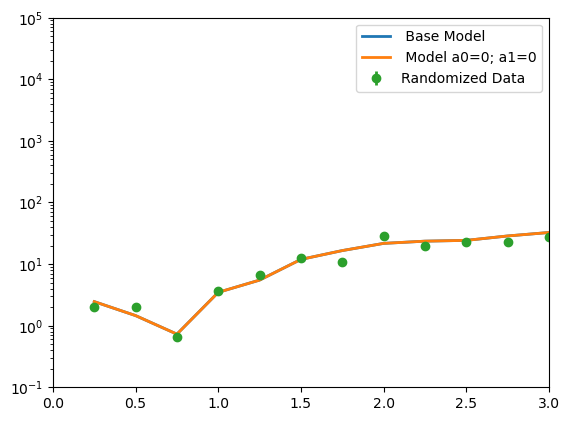

In [67]:
fig0 = plt.figure()
plt.plot(energy_nld_talys,nld_talys,label=f' Base Model',lw=2)
plt.plot(energy_nld_talys,test_nld,label=f' Model a0={p}; a1={c}',lw=2)
plt.errorbar(energy_nld_talys,rand_nld,yerr=test_nld/10,fmt='o',label=f'Randomized Data ',lw=2)

plt.xlim(0,3)
plt.ylim(.1,1e5)
plt.yscale("log")
plt.legend()
plt.show()

In [69]:
#Test version of model adjustment function
def fit_model_test(param0,param1,erg):
    #NLD    
    #Make alteration
    new_energy = energy_nld_talys-param0 #ptable shift
    exp = np.exp(param1*np.sqrt(new_energy)) #ctable shift
    shift_nld = np.interp(new_energy,energy_nld_talys,nld_talys,left=np.nan,right=np.nan)
    n_nld = exp*shift_nld
    
    
    #Make errors for test
    #nld_err = np.ones((1,len(n_nld)))*n_nld/10
    return new_energy, n_nld

In [71]:
#Test version of Likelihood function
def likely(param0,param1,points):
    params = param0,param1
    sigmas = points/10
    model_erg, model_nld= fit_model_test(param0,param1,energy_nld_talys)
    #if model_energy[0] == -np.inf:
    #    return -np.inf
# Mask to match vectors based on energy range
    valid = np.isfinite(model_nld) # mask NaN
    
    model_valid = model_nld[valid]
    points_valid = points[valid]
    sigmas_valid = sigmas[valid]
    
#ensure vector shapes match    
    assert model_nld.ndim == points_valid.ndim == sigmas_valid.ndim == 1 
# Chi^2    
    resid = (points_valid - model_valid) / sigmas_valid
    ll = -0.5 * (np.sum(resid**2) + np.sum(np.log(2 * np.pi * sigmas_valid**2)))
    return ll,param0,param1

In [73]:
#Test likelihood with random distributions
np.random.seed()
results = []
for i in range(0,10000):
    #parhaps use a cost function to minimize ask Chat
    a0_guess = np.random.uniform(-3,3)#p
    a1_guess = np.random.uniform(-3,3)#c
    
    llv = likely(a0_guess,a1_guess,test_nld)
    results.append(llv)


C:\Users\th3C0\AppData\Local\Temp\ipykernel_10888\3567997876.py:6: RuntimeWarning: invalid value encountered in sqrt
  exp = np.exp(param1*np.sqrt(new_energy)) #ctable shift


In [75]:
best_a0 = max(results)[1]
best_a1 = max(results)[2]
#print(best_a0,best_a1)


In [77]:
#Get x,y arrays using "best" parameters found in random guess
def cp_2D_plot(param0,param1):
    #Calculate new Talys with c p suggestion
    new_energy = energy_nld_talys-param0 #ptable shift
    shift_nld = np.interp(energy_nld_talys,new_energy,nld_talys,left=np.nan,right=np.nan)
    exp = np.exp(param1*np.sqrt(new_energy)) #ctable shift
    n_nld = exp*shift_nld
    new_nld = np.interp(energy_nld_talys,new_energy,n_nld,left=np.nan,right=np.nan)

    return new_energy, new_nld #nld_scaled

In [83]:
best_erg,best_nld = fit_model_test(best_a0,best_a1,test_nld)
#print(best_model)
guess_erg, guess_nld = fit_model_test(p,c,test_nld)

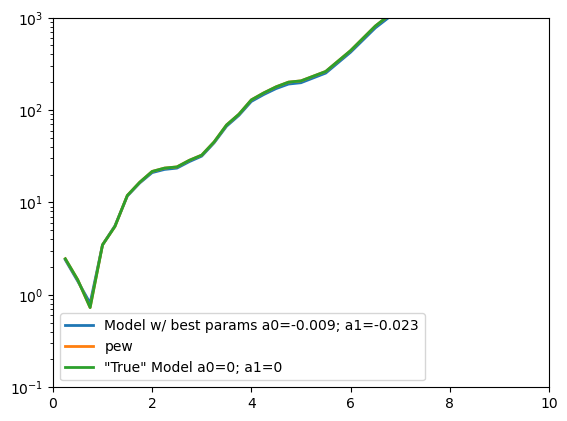

In [85]:
#Plot "best" parameter model to verify quality of functions
fig1 = plt.figure()
plt.plot(energy_nld_talys,best_nld,label=f'Model w/ best params a0={best_a0:.3f}; a1={best_a1:.3f}',lw=2)
plt.plot(energy_nld_talys,guess_nld,label=f'pew',lw=2)

plt.plot(energy_nld_talys,test_nld,label=f'"True" Model a0={p}; a1={c}',lw=2)
#plt.errorbar(energy_nld_talys,nld_shift,yerr=nld_err[0],fmt='o',label=f'Randomized Data ',lw=2)
plt.xlim(0,10)
plt.ylim(.1,1000)
plt.yscale("log")
plt.legend()
plt.show()

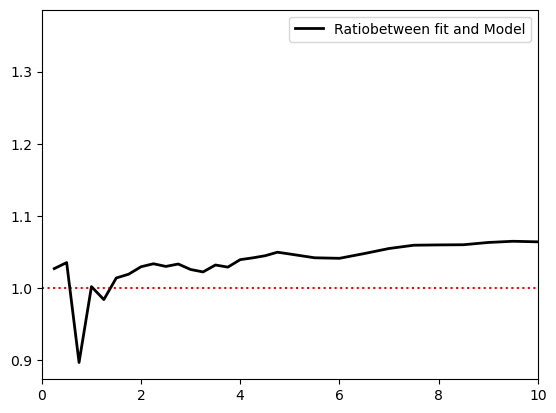

In [89]:
#Plot "best" parameter model to verify quality of functions
figgy = plt.figure()
plt.hlines(1,0,50,linestyle='dotted',color = 'r')
plt.plot(energy_nld_talys,test_nld/best_nld,color='black',label=f'Ratiobetween fit and Model',lw=2)


plt.xlim(0,10)
#plt.ylim(-1e3,1)
#plt.yscale("log")
plt.legend()
plt.show()

Begin Bayes

In [92]:
def pres_mtx_2D(sigma1,sigma2):
    
    # ==== Set your correlations ====
    rho12 = 0.7   # correlation between param1 and param2

    
    # ==== Build covariance matrix ====
    cov = np.array([
        [sigma1**2,  rho12*sigma1*sigma2],
        [rho12*sigma1*sigma2,  sigma2**2],
        ])
    
    # Optional: check positive definiteness (required!)
    eigvals = np.linalg.eigvals(cov)
    if np.any(eigvals <= 0):
        raise ValueError("Covariance matrix is not positive-definite. Adjust σ or ρ values.")
    
    # ==== Compute precision matrix ====
    precision = np.linalg.inv(cov)
    
    print("Covariance matrix Σ:\n", cov)
    print("\nPrecision matrix Λ = Σ⁻¹:\n", precision)
    
    return precision

In [94]:
def nld_model(params,energy):
    param0,param1 = params
    #Calculate new Talys with c p suggestion
    #ptable shift
    shifted_energy = energy_nld_talys-param0 
    shifted_nld = np.interp(shifted_energy,energy_nld_talys, nld_talys,left=np.nan,right=np.nan)
    #ctable shift
    exp = np.exp(param1*np.sqrt(np.clip(shifted_energy,0,None)))
    
    new_nld = exp*shifted_nld
    
    return new_nld

In [96]:
'''
def likelihood(params,arguments): #returns e^-chi2
    data, model, sigmas = arguments
    likelihood_log_val=0
    
    for i in range(len(data[0])):
        likelihood_log_val=likelihood_log_val-1/2*((data[1][i] - model(data[0][i],params)) / sigmas[i])**2\
        -np.log(2*np.pi*sigmas[i]**2)/2   
    return np.exp(likelihood_log_val)

def prior(params_vals,arguments):
    p_limit = 10
    c_limit = 10

    params0,params0_Cov_Inv_matrix=arguments
    mu=np.array(params_vals)-np.array(params0)
    params_size=len(params_vals)
    
    if params_vals[0]+min(data[0]) > max(data[0]) or params_vals[0]+min(data[0]) < 0:
        return -np.inf
    
    if np.abs(params_vals[0])> p_limit or np.abs(params_vals[1]) > c_limit:
        return -np.inf
    else:
        pr = (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2)
        return np.log(pr)
'''

'\ndef likelihood(params,arguments): #returns e^-chi2\n    data, model, sigmas = arguments\n    likelihood_log_val=0\n    \n    for i in range(len(data[0])):\n        likelihood_log_val=likelihood_log_val-1/2*((data[1][i] - model(data[0][i],params)) / sigmas[i])**2        -np.log(2*np.pi*sigmas[i]**2)/2   \n    return np.exp(likelihood_log_val)\n\ndef prior(params_vals,arguments):\n    p_limit = 10\n    c_limit = 10\n\n    params0,params0_Cov_Inv_matrix=arguments\n    mu=np.array(params_vals)-np.array(params0)\n    params_size=len(params_vals)\n    \n    if params_vals[0]+min(data[0]) > max(data[0]) or params_vals[0]+min(data[0]) < 0:\n        return -np.inf\n    \n    if np.abs(params_vals[0])> p_limit or np.abs(params_vals[1]) > c_limit:\n        return -np.inf\n    else:\n        pr = (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2)\n        return np.log(pr)\n'

In [286]:
def prior(params_vals, arguments):
    # arguments = (params0, inv_cov)   # inv_cov = Σ^{-1}
    params0, inv_cov = arguments

    p_limit = 5
    c_limit = 10

    # ----- HARD BOUNDARIES / HEAVYSIDE FUNCTIONS -----
    # If outside allowed region → impossible → log-prior = -∞
    if (abs(params_vals[0]) > p_limit or
        abs(params_vals[1]) > c_limit or
        params_vals[0] + min(data[0]) > max(data[0]) or
        params_vals[0] + min(data[0]) < 0):
        return -np.inf
    
    # ----- GAUSSIAN LOG PRIOR -----
    mu = np.asarray(params_vals) - np.asarray(params0)
    d = len(mu)

    # Quadratic form
    quad = mu @ (inv_cov @ mu)

    # log(det(inv_cov)) in a stable way
    sign, logdet_inv = np.linalg.slogdet(inv_cov)
    if sign <= 0:
        return -np.inf   # inv_cov must be positive definite

    # Log probability of multivariate Gaussian
    log_prior = -0.5 * (d * np.log(2*np.pi) - logdet_inv + quad)

    return log_prior


In [288]:
def loglikelihood(params,arguments): #log likelihood returns chi2
# Unpack
    data, model, sigmas = arguments
    energy_data,points = data
# Calculate Model
    model_nld = model(params, energy_data)
    model_nld = np.interp(energy_data,shifted_energy,new_nld,left=np.nan,right=np.nan)
    #if model_energy[0] == -np.inf:
    #    return -np.inf
# Mask to match vectors based on energy range
    valid = np.isfinite(model_nld) # mask NaN
   # if np.sum(valid) < 3: # remove answers with less than 3 points 
   #     return -np.inf
    model_valid = model_nld[valid]
    points_valid = points[valid]
    sigmas_valid = sigmas[valid]
    
#ensure vector shapes match    
    assert model_nld.ndim == points_valid.ndim == sigmas_valid.ndim == 1 
# Chi^2    
    resid = (points_valid - model_valid) / sigmas_valid
    ll = -0.5 * (np.sum(resid**2) + np.sum(np.log(2 * np.pi * sigmas_valid**2)))
    return ll

In [290]:
#n = np.interp(50,energy_nld_talys,new_nld,left=np.nan, right=np.nan)
#print(n)

In [292]:
# Define the Metropolis algorithm
def metropolis(burn,data,sigma, prior,prior_arguments, likelihood,model,\
               num_iterations, step_size):
#     step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data, model, sigma]
    initial_parameters=prior_arguments[0]
    #thermalizing
    # Set the initial state of the chain
    params_current=initial_parameters
    params_list=[]
    posterior_list=[]
    chi2=[]
    acceptance_times=0
    out = 0
    cov_step_size=np.diag(step_size)**2
    #cov_step_size = cov_mtx_2D(step_size[0],step_size[1],1,1)
    posterior_current=(likelihood(params_current,likelihood_arguments))+(prior(params_current,prior_arguments))
    
    # Run the Metropolis-Hastings algorithm for burning
    print('Burning')
    
    for i in range(burn_samples):
        # Propose a new state for the chain
        #params_current[0] = 0
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        #params_proposed[0] = 0
        pri = prior(params_proposed,prior_arguments)
        if np.abs(pri) != np.inf:
            llh = likelihood(params_proposed,likelihood_arguments)
        else:
            llh = -np.inf
        posterior_proposed=llh+pri
        # Calculate the acceptance probability
        #scaled_factor = scale_by_digits(posterior_proposed,posterior_current)
        # ratio = np.exp((-np.abs(posterior_proposed)) - (-np.abs(posterior_current)))#/scaled_factor)   #posterior_proposed/posterior_current
        ratio = np.exp(((posterior_proposed)) - ((posterior_current)))#/scaled_factor)   #posterior_proposed/posterior_current
        if np.isnan(ratio) == True or np.abs(posterior_proposed) == np.inf:
            ratio = 0
        acceptance_prob = min(1, ratio )
        #print(f'i = {i}, params proposed = {params_proposed} {posterior_proposed},params current{params_current} {posterior_current}, acceptance prob = {acceptance_prob}')
      
        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    print('Recording')
    for i in range(num_iterations):
        
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        #params_proposed[0] = 0
        #params_proposed[0] = 2.3 * np.random.uniform(.9,1.1) #testing
        #params_proposed[1] = c_table[i]
        pri = prior(params_proposed,prior_arguments)
        if pri != -np.inf:
            llh = likelihood(params_proposed,likelihood_arguments)
        else:
            llh = -np.inf
        posterior_proposed=llh+pri
        

        # Calculate the acceptance probability
        #scaled_factor = scale_by_digits(posterior_proposed,posterior_current)
        ratio = np.exp((posterior_proposed) - ((posterior_current)))#/scaled_factor)   #posterior_proposed/posterior_current
        if np.isnan(ratio) == True or np.abs(posterior_proposed) == np.inf:
            ratio = 0
        acceptance_prob = min(1, ratio)
        # Accept or reject the proposal
        #print(f'i = {i}, llh = {llh}, params proposed = {params_proposed} {posterior_proposed},params current{params_current} {posterior_current}, acceptance prob = {acceptance_prob}')
        if np.random.uniform() < acceptance_prob:
            
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1
        #if ratio == -1:
        #    out=out+1
        # Store the current state
        if i%10 == 0:#introduce lag to reduce autocorrelation between succsessive params
            params_list.append(params_current)
            posterior_list.append(posterior_current)
            chi2.append(likelihood(params_current,likelihood_arguments))

    #Rule of thumb acceptance is around 50%. 
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see.
    
    print(f'Accepted {acceptance_times/num_iterations*100}%')
    print(f'Rejected {(1-(acceptance_times/num_iterations))*100}%')
    print(f'Outliers {out/num_iterations*100}%')
    return(np.array(params_list),np.array(posterior_list),np.array(chi2),acceptance_times/num_iterations*100)



In [294]:
#Read data

df_nld_data=pd.read_csv("Data/stats_nld.csv",header=0)
df_nld_420=pd.read_csv("Data/420keV_nld.cnt",header=None)
#df_nld_data= df_nld_talys.drop(df_nld_talys.index[:2]) #drop weird dip at beginning
#df_nld_data.loc[len(df_nld_data)] = [len(df_nld_data),8,275,100]
'''
energy_data=df_nld_data["E_MeV"][:71].values # as numpy array
nld_data=df_nld_data["mean"][:71].values 
err_data=df_nld_data["total_err"][:71].values
'''
energy_data = []
for i in range(int(len(df_nld_420)/2)):
    e_dat = 0.420*i - 0.8390
    energy_data.append(e_dat)
energy_420 = np.array(energy_data)
nld_420=df_nld_420[:28].values
err_420=df_nld_420[28:].values
energy_data = np.array(energy_data).flatten()
nld_data = nld_420.flatten()
err_data = err_420.flatten()
print(energy_data)

[-8.3900e-01 -4.1900e-01  1.0000e-03  4.2100e-01  8.4100e-01  1.2610e+00
  1.6810e+00  2.1010e+00  2.5210e+00  2.9410e+00  3.3610e+00  3.7810e+00
  4.2010e+00  4.6210e+00  5.0410e+00  5.4610e+00  5.8810e+00  6.3010e+00
  6.7210e+00  7.1410e+00  7.5610e+00  7.9810e+00  8.4010e+00  8.8210e+00
  9.2410e+00  9.6610e+00  1.0081e+01  1.0501e+01]


In [296]:
#df_nld_data #np.r_ lets you select multiple regions

In [298]:

data_high = 10
data_low = 5.1
data_mask = (energy_data>data_low) & (energy_data<data_high) & (nld_data > 0)
erg_dat = energy_data[data_mask]
nld_dat = nld_data[data_mask]
err_dat = err_data[data_mask]


In [385]:
np.random.seed()
burn_samples=50000
num_iter = 200000

data = [erg_dat,nld_dat]
error = err_dat
a0,a1 = 2.3,0

#Step Sizes
#For the first trials have both a0 & a1 turned on to get a sense of the full width of the 
#        parameter distributions (use the x axis of the single parameter scatter plot). 
#        The ratio of the widths should be proportional to the ratio of the step sizes.

a0_step = 0.7
step_ratio =4.5/0.7

cov_mtx = pres_mtx_2D(1,1) #for 2 correlated parameters, this function gives a 2D covarience matrix

#Setting up the prior
prior_arguments_A=[[a0,a1],cov_mtx] #assumes parameters are correlated
#prior_arguments_A=[[a0,a1],np.linalg.inv(np.diag([.5**2,.5**2]))] #this assumes parameters are uncorrelated

#Doing the Metropolis sampling num_iter times
start = time.time()
results_A=metropolis(burn_samples,data,error, prior,prior_arguments_A, loglikelihood,nld_model,num_iter, [a0_step,a0_step/step_ratio])
end = time.time()
total = end-start
minutes,seconds = divmod(total,60)
print(f"Elapsed Time {int(minutes)}:{seconds:.2f}")
all_chains =results_A[0] # nD parameter array
all_chi2 = results_A[2]  # chi^2 array
print(all_chains)

Covariance matrix Σ:
 [[1.  0.7]
 [0.7 1. ]]

Precision matrix Λ = Σ⁻¹:
 [[ 1.96078431 -1.37254902]
 [-1.37254902  1.96078431]]
Burning
Recording
Accepted 45.76%
Rejected 54.24%
Outliers 0.0%
Elapsed Time 0:27.91
[[ 0.43998667 -0.92816497]
 [-0.23219254 -0.98135373]
 [ 1.27089839 -0.83783507]
 ...
 [ 0.91167957 -0.73027149]
 [ 0.55178964 -0.89924334]
 [ 2.48658977 -0.85094021]]


Parameter Visualization

In [387]:
a0_med = np.median(all_chains[:,0])
a1_med = np.median(all_chains[:,1])
a0_avg = np.average(all_chains[:,0])
a1_avg = np.average(all_chains[:,1])
print(f'a0 median {a0_med}')
print(f'a1 median {a1_med}')
print(f'a0 average {a0_avg}')
print(f'a1 average {a1_avg}')

a0 median 1.715922087682043
a1 median -0.8304380137377041
a0 average 1.7097927433834688
a1 average -0.8371308297517731


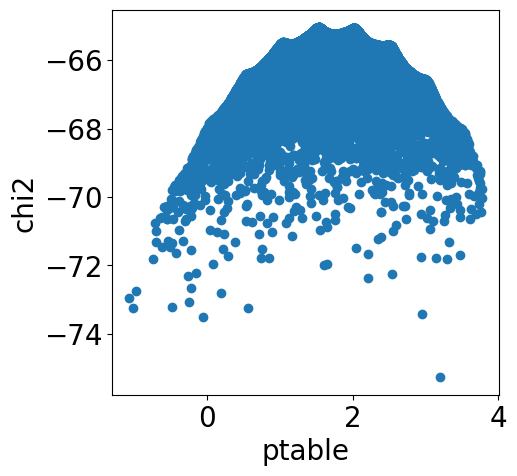

In [388]:
fig, axs = plt.subplots(figsize=(5,5),dpi=100)
axs.scatter(all_chains[:,0], results_A[1])
#axs.vlines(0,-5,0,color = 'r')
#plt.legend(fontsize=15,frameon=True, edgecolor='black')
#plt.xlim(0.6,.8)
#plt.ylim(-13,-10)

#plt.yscale("log")

axs.set_xlabel('ptable',fontsize=20)
axs.set_ylabel('chi2',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

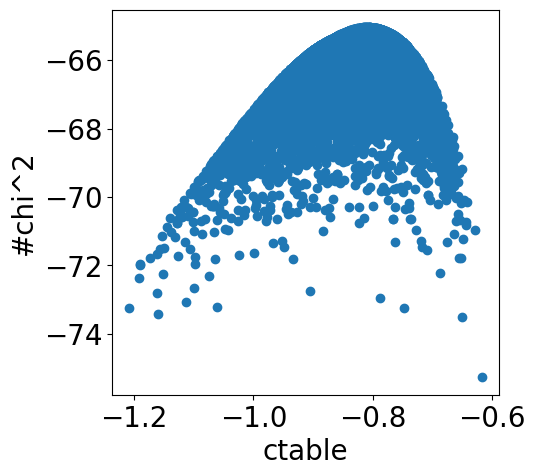

In [389]:
fig, axs = plt.subplots(figsize=(5,5),dpi=100)
axs.scatter(all_chains[:,1], results_A[1])
#axs.vlines(0,-5,0,color = 'r')
#plt.legend(fontsize=15,frameon=True, edgecolor='black')
#plt.xlim(-1.,-.5)
#plt.ylim(-13,-10)
#plt.yscale("log")

axs.set_xlabel('ctable',fontsize=20)
axs.set_ylabel('#chi^2',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

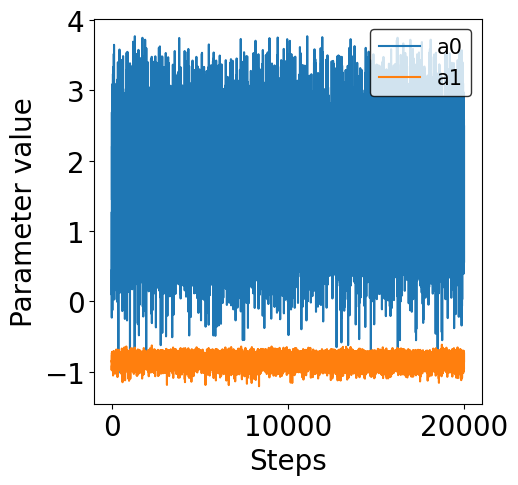

In [390]:
fig, ax = plt.subplots(figsize=(5,5),dpi=100)
ax.plot(np.linspace(0,len(all_chains[:,0]),len(all_chains[:,0])),all_chains[:,0],label = 'a0')
ax.plot(np.linspace(0,len(all_chains[:,1]),len(all_chains[:,1])),all_chains[:,1],label = 'a1')
plt.legend(fontsize=15,frameon=True, edgecolor='black')

#plt.ylim(-.05,0.1)

ax.set_xlabel('Steps',fontsize=20)
ax.set_ylabel('Parameter value',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

In [396]:
'''
start = time.time()
p_val = all_chains[:, 0]
c_val = all_chains[:, 1]

# Create grid to interpolate onto
pi = np.linspace(p_val.min(), p_val.max(), int(len(all_chains)/25))
ci = np.linspace(c_val.min(), c_val.max(), int(len(all_chains)/25))
pi, ci = np.meshgrid(pi, ci)


counts = np.zeros_like(pi)
for i in range(len(p_val)):
    # Find nearest grid cell
    p_idx = np.abs(pi[0, :] - p_val[i]).argmin()
    c_idx = np.abs(ci[:, 0] - c_val[i]).argmin()
    counts[c_idx, p_idx] += 1
    
# Interpolate Z values onto grid
chii = griddata((p_val, c_val), all_chi2, (pi, ci), method='cubic')

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(pi, ci, chii, facecolors=plt.cm.viridis(counts / counts.max()), edgecolor='none')

ax.set_xlabel('p table')
ax.set_ylabel('c table')
ax.set_zlabel('Log Likelihood')
mappable = plt.cm.ScalarMappable(cmap='viridis')
mappable.set_array(counts)
#fig.colorbar(mappable,  ax=ax,label='Number of Z points')

plt.show()
end = time.time()
total = end-start
minutes,seconds = divmod(total,60)
print(f"Elapsed Time {int(minutes)}:{seconds:.2f}")
'''

'\nstart = time.time()\np_val = all_chains[:, 0]\nc_val = all_chains[:, 1]\n\n# Create grid to interpolate onto\npi = np.linspace(p_val.min(), p_val.max(), int(len(all_chains)/25))\nci = np.linspace(c_val.min(), c_val.max(), int(len(all_chains)/25))\npi, ci = np.meshgrid(pi, ci)\n\n\ncounts = np.zeros_like(pi)\nfor i in range(len(p_val)):\n    # Find nearest grid cell\n    p_idx = np.abs(pi[0, :] - p_val[i]).argmin()\n    c_idx = np.abs(ci[:, 0] - c_val[i]).argmin()\n    counts[c_idx, p_idx] += 1\n    \n# Interpolate Z values onto grid\nchii = griddata((p_val, c_val), all_chi2, (pi, ci), method=\'cubic\')\n\n# Create 3D plot\nfig = plt.figure()\nax = fig.add_subplot(111, projection=\'3d\')\nsurf = ax.plot_surface(pi, ci, chii, facecolors=plt.cm.viridis(counts / counts.max()), edgecolor=\'none\')\n\nax.set_xlabel(\'p table\')\nax.set_ylabel(\'c table\')\nax.set_zlabel(\'Log Likelihood\')\nmappable = plt.cm.ScalarMappable(cmap=\'viridis\')\nmappable.set_array(counts)\n#fig.colorbar(mappa

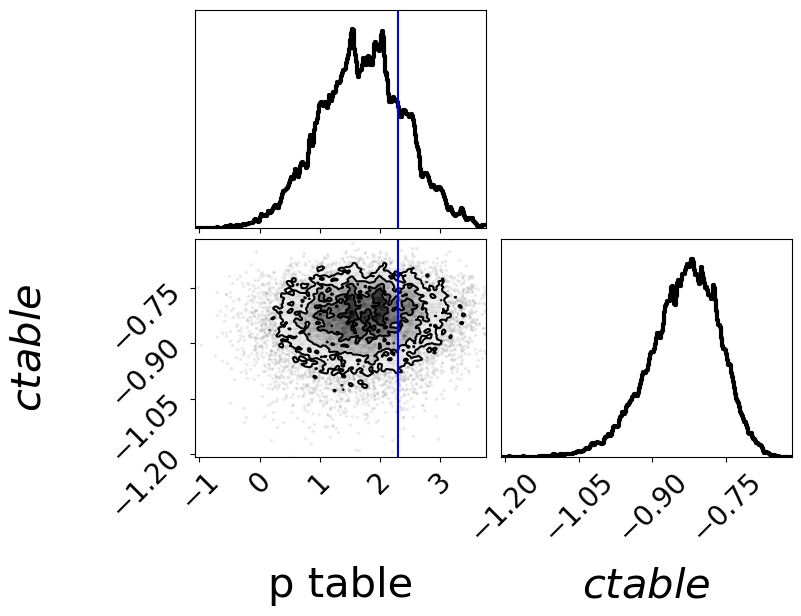

In [398]:
figure = corner.corner(all_chains,
    labels=[r'p table',r'$c table$'],
    labelpad=0.2,
                       bins=300,
    label_kwargs={"fontsize":30},
                      hist_kwargs= {"linewidth":3},
    quantiles=None
                        ,truths=[a0,a1], truth_color='b'
                       ,
    smooth=(1.7)
                       ,
    smooth1d=1.0
                      )


width = 8
height = 6
#figure.vlines(0,-5,0,color = 'r')
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)


Gaussian Mixure Model GMM for clustering (Like a cut around the 2D peaks)
GMM models the paramaters as a mixture of several Gaussians
"The samples come from several overlapping multivariate normal distributions"
Great for correlated parameters (ellipsiod shapes in the corner plot), also assumes each cluster is a 2D ellipse


In [400]:
#Use Bayesian Information Criterion to Determine number of clusters
bics = []
models = []
for k in range (1,25): # k is how many clusters are assumed to be in the parameter space (number of gaussian components)
    gmm =  GaussianMixture(n_components=k, covariance_type='full',random_state=0)#cov_type = full means each component has its own full cov matrix, allows clusters to be any ellipsoidal shape
    gmm.fit(all_chains)
    bics.append(gmm.bic(all_chains))
    models.append(gmm)
best_k = np.argmin(bics)
best_gmm = models[best_k]
print(bics)
print(f'Best number of clusters (lowest BIC) = {best_k+1}')

labels = best_gmm.predict(all_chains) #labels cp pairs from 0 to besk_k

[-5288.5313317607715, -5294.171259498746, -5145.88612045264, -5076.279981445168, -5030.220176323777, -5079.416053970002, -5069.360432673829, -5423.347577657976, -5479.164150463734, -5334.268251744236, -5282.128748415827, -5342.909609447963, -5211.041278676994, -5126.420247993617, -5035.019360593615, -4991.879793784896, -4939.275221979304, -4884.609561460851, -4871.618295854723, -5093.006413879119, -5112.68310810592, -5012.607899506379, -4965.779668037737, -4964.182527748087]
Best number of clusters (lowest BIC) = 9


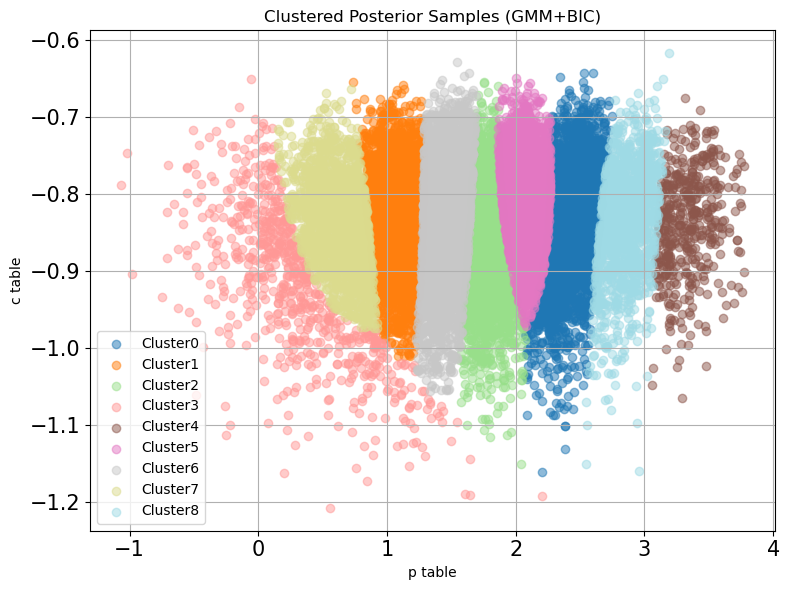

In [403]:
#Visualize clusters in param space
colors = plt.get_cmap("tab20", best_k + 1).colors
plt.figure(figsize=(8,6))
for i in range(best_k+1):
    cluster_samples = all_chains[labels == i]
    plt.scatter(cluster_samples[:,0],cluster_samples[:,1], label=f'Cluster{i}', alpha = .5,color = colors[i])
plt.xlabel("p table")
plt.ylabel("c table")
plt.title('Clustered Posterior Samples (GMM+BIC)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The various colors show how GMM divided posterior (corner plot) into multiple regions. 

In [406]:
def plot_gmm_ellipses(gmm, ax, colors):
    for i, (mean, cov) in enumerate(zip(gmm.means_, gmm.covariances_)):
        v, w = np.linalg.eigh(cov)
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
        u = w[0] / np.linalg.norm(w[0])

        angle = np.degrees(np.arctan2(u[1], u[0]))
        ell = Ellipse(xy=mean, width=v[0], height=v[1], angle=angle, color=colors[i], alpha=1)
        ax.add_patch(ell)

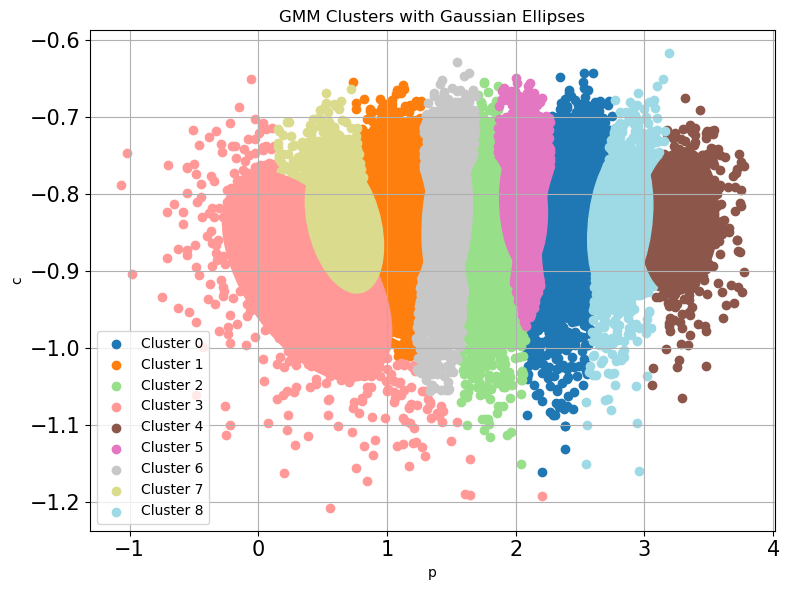

In [408]:

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(best_k + 1):
    cluster_samples = all_chains[labels == i]
    ax.scatter(cluster_samples[:, 0], cluster_samples[:, 1], label=f"Cluster {i}", alpha=1, color=colors[i])

plot_gmm_ellipses(best_gmm, ax, colors)

ax.set_xlabel("p")
ax.set_ylabel("c")
ax.set_title("GMM Clusters with Gaussian Ellipses")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The clusters form the main modes(hot spots) in the corner plot.
These regions are gaussian shaped approximations of local high probablility regions of the parameters space.
They can be though of as subcomponents of the main blobs in the corner plot.



In [411]:
#group the clusters into the main regions
region_map = {  0:0, 1:0,2:0,
                3:0,4:0,5:0,
                6:0,7:0,
                8:0#,9:0,10:0,
                #3:4,5:5
               #,12:0,13:0,14:0,
                #15:0,16:0,17:0,18:0,19:0,20:0,21:0,22:0,23:0
               }

#Define Model

In [414]:
def cp_2D_plot(p,c):
    #Calculate new Talys with c p suggestion
    #NLD    
    #Make alteration
    new_energy = energy_nld_talys-p #ptable shift
    exp = np.exp(c*np.sqrt(new_energy)) #ctable shift
    shift_nld = np.interp(new_energy,energy_nld_talys,nld_talys,left=np.nan,right=np.nan)
    n_nld = exp*shift_nld
    new_nld = np.interp(energy_data,new_energy,n_nld,left=np.nan,right=np.nan)
    valid_mask = np.isfinite(new_nld)
    nld_valid = new_nld[valid_mask]
    energy_valid = energy_data[valid_mask]
    #Make errors for test
    #nld_err = np.ones((1,len(n_nld)))*n_nld/10
    return energy_valid, nld_valid

#HDI

In [417]:
region_map

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0}

In [419]:

# -----------------------------
# Plot HDI Bands by Region
# -----------------------------
def compute_HDI_band_by_modes(all_chains, cp_2D_plot, sub_labels, region_map,
                              hdi_prob=0.95, n_grid=200):
    """
    Compute posterior predictive HDI bands for major modes defined by region_map.

    Parameters
    ----------
    all_chains : array-like, shape (n_samples, 2)
        MCMC samples of parameters (p, c).
    cp_2D_plot : function
        Function that takes (p, c) and returns (x, y) arrays.
    sub_labels : array-like, shape (n_samples,)
        Subcomponent index for each sample (from your GMM prediction).
    region_map : dict
        Mapping {subcomponent_idx : major_region_idx}.
    hdi_prob : float
        Desired HDI probability.
    n_grid : int
        Number of points for the common interpolation grid.

    Returns
    -------
    mode_results : dict
        Keys are major region indices, values are dicts with:
            {
              "x_common": ndarray,
              "y_median": ndarray,
              "hdi_low": ndarray,
              "hdi_high": ndarray,
              "y_interp": ndarray
            }
    """
    mode_results = {}

    # Translate sub_labels into major region labels
    major_labels = np.array([region_map.get(sub, -1) for sub in sub_labels])

    for region in np.unique(list(region_map.values())):
        idx = np.where(major_labels == region)[0]
        chains_region = all_chains[idx]

        results = [cp_2D_plot(p, c) for p, c in chains_region]

        # Common grid
        x_min = max(r[0].min() for r in results)
        x_max = min(r[0].max() for r in results)
        x_common = np.linspace(x_min, x_max, n_grid)

        # Interpolation
        y_interp = []
        for x, y in results:
            f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
            y_interp.append(f(x_common))
        y_interp = np.array(y_interp)

        # HDI
        hdi_low, hdi_high = [], []
        for j in range(y_interp.shape[1]):
            vals = y_interp[:, j]
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                hdi = az.hdi(vals, hdi_prob=hdi_prob)
                hdi_low.append(hdi[0])
                hdi_high.append(hdi[1])
            else:
                hdi_low.append(np.nan)
                hdi_high.append(np.nan)

        y_median = np.nanmedian(y_interp, axis=0)

        mode_results[region] = {
            "x_common": x_common,
            "y_median": y_median,
            "hdi_low": np.array(hdi_low),
            "hdi_high": np.array(hdi_high),
            "y_interp": y_interp
        }

    return mode_results



In [421]:
mode_results = compute_HDI_band_by_modes(all_chains, cp_2D_plot, labels, region_map)

C:\Users\th3C0\AppData\Local\Temp\ipykernel_10888\2763746799.py:6: RuntimeWarning: invalid value encountered in sqrt
  exp = np.exp(c*np.sqrt(new_energy)) #ctable shift


In [422]:
def compute_HDI_band(all_chains, cp_2D_plot, hdi_prob=0.95, n_grid=200):
    """
    Compute posterior predictive HDI bands from MCMC chains.

    Parameters
    ----------
    all_chains : array-like, shape (n_samples, 2)
        MCMC samples of parameters (p, c).
    cp_2D_plot : function
        Function that takes (p, c) and returns (x, y) arrays.
    hdi_prob : float
        Desired HDI probability (default=0.95).
    n_grid : int
        Number of points for the common interpolation grid.

    Returns
    -------
    x_common : ndarray
        Common x-grid for all interpolated curves.
    y_median : ndarray
        Median posterior prediction at each x.
    hdi_low : ndarray
        Lower bound of HDI.
    hdi_high : ndarray
        Upper bound of HDI.
    y_interp : ndarray, shape (n_samples, n_grid)
        All interpolated posterior predictions.
    """
    results = [cp_2D_plot(p, c) for p, c in all_chains]

    # Common grid across all models
    x_min = max(r[0].min() for r in results)
    x_max = min(r[0].max() for r in results)
    x_common = np.linspace(x_min, x_max, n_grid)

    # Interpolation
    y_interp = []
    for x, y in results:
        f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
        y_interp.append(f(x_common))
    y_interp = np.array(y_interp)

    # Compute HDI at each x
    hdi_low, hdi_high = [], []
    for j in range(y_interp.shape[1]):
        vals = y_interp[:, j]
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            hdi = az.hdi(vals, hdi_prob=hdi_prob)
            hdi_low.append(hdi[0])
            hdi_high.append(hdi[1])
        else:
            hdi_low.append(np.nan)
            hdi_high.append(np.nan)

    y_median = np.nanmedian(y_interp, axis=0)
    return x_common, y_median, np.array(hdi_low), np.array(hdi_high), y_interp


In [423]:
def plot_HDI_band(x_hdi, y_median, hdi_low, hdi_high,
                  exp_data_path=None, extra_curves=None,
                  xlabel="Energy (MeV)", ylabel="Observable",
                  title="Posterior Predictive HDI Band"):
    """
    Plot posterior predictive HDI band with optional overlays.
    """
    plt.figure(figsize=(8,5))
   

    # Overlay experimental Oslo data
    if exp_data_path is not None:
        df_exp = pd.read_csv(exp_data_path)
        if "Ex" in df_exp.columns and "NLD" in df_exp.columns:
            plt.errorbar(df_exp["Ex"], df_exp["NLD"], 
                         yerr=df_exp.get("NLD_err", None),
                         fmt="o", color="red", label="Oslo data", alpha=0.7)

    # Overlay any extra curves
    if extra_curves is not None:
        for curve in extra_curves:
            plt.plot(curve["x"], curve["y"], 
                     label=curve.get("label", "Extra curve"),
                     **curve.get("style", {}))

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

In [424]:
#compute HDI from chains
x_hdi, y_median, hdi_low, hdi_high, y_all = compute_HDI_band(all_chains, cp_2D_plot, hdi_prob=0.95)


C:\Users\th3C0\AppData\Local\Temp\ipykernel_10888\2763746799.py:6: RuntimeWarning: invalid value encountered in sqrt
  exp = np.exp(c*np.sqrt(new_energy)) #ctable shift


In [425]:
def compute_CI_bands_by_modes(all_chains, cp_2D_plot, sub_labels, region_map,
                              ci_level=95, n_grid=200):
    """
    Compute percentile CI bands for each major posterior mode.

    Parameters
    ----------
    all_chains : array-like, shape (n_samples, 2)
        MCMC samples of parameters.
    cp_2D_plot : function
        Function that takes (p, c) and returns (x, y).
    sub_labels : array-like, shape (n_samples,)
        Subcomponent index for each sample.
    region_map : dict
        Mapping {subcomponent_idx : major_region_idx}.
    ci_level : float
        Credible interval width in percent (e.g. 95).
    n_grid : int
        Number of points in common interpolation grid.

    Returns
    -------
    mode_results : dict
        Keys = major region indices.
        Each value = dict with arrays:
            {
              "x_common": ndarray,
              "median": ndarray,
              "lower": ndarray,
              "upper": ndarray
            }
    """
    mode_results = {}
    major_labels = np.array([region_map.get(sub, -1) for sub in sub_labels])
    regions = np.unique(list(region_map.values()))

    for region in regions:
        idx = np.where(major_labels == region)[0]
        chains_region = all_chains[idx]

        results = [cp_2D_plot(p, c) for p, c in chains_region]

        # Common grid
        x_min = max(r[0].min() for r in results)
        x_max = min(r[0].max() for r in results)
        x_common = np.linspace(x_min, x_max, n_grid)

        # Interpolation
        y_interp = []
        for x, y in results:
            f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
            y_interp.append(f(x_common))
        y_interp = np.array(y_interp)

        # Percentile CI
        lower = np.nanpercentile(y_interp, (100-ci_level)/2, axis=0)
        upper = np.nanpercentile(y_interp, 100-(100-ci_level)/2, axis=0)
        median = np.nanpercentile(y_interp, 50, axis=0)

        mode_results[region] = {
            "x_common": x_common,
            "median": median,
            "lower": lower,
            "upper": upper
        }

    return mode_results


In [429]:
ci_results = compute_CI_bands_by_modes(all_chains, cp_2D_plot, labels, region_map, ci_level=95)


C:\Users\th3C0\AppData\Local\Temp\ipykernel_10888\2763746799.py:6: RuntimeWarning: invalid value encountered in sqrt
  exp = np.exp(c*np.sqrt(new_energy)) #ctable shift


In [430]:
rng = np.random.default_rng()
alpha_rand = rng.choice(all_chains,(int(len(all_chains)/10)),replace=False)
func_rand=[cp_2D_plot(alpha[0],alpha[1]) for alpha in alpha_rand]
hannah_erg,hannah_nld = cp_2D_plot(0.731874857404499,-0.6814810256589781)
avg_erg,avg_nld = cp_2D_plot(a0_avg,a1_avg)

peak1_erg,peak1_nld = cp_2D_plot(1.15,-0.8)
peak2_erg,peak2_nld = cp_2D_plot(1.42,-.55)
peak3_erg,peak3_nld = cp_2D_plot(1.75,-.38)

C:\Users\th3C0\AppData\Local\Temp\ipykernel_10888\2763746799.py:6: RuntimeWarning: invalid value encountered in sqrt
  exp = np.exp(c*np.sqrt(new_energy)) #ctable shift


In [433]:
print(type(func_rand))
print(len(func_rand))

types = [type(f) for f in func_rand]
unique_types = set(types)
print("Unique types in func_rand:", unique_types)

shapes = [np.shape(f[1]) for f in func_rand]
unique_shapes = set(shapes)
print("Unique shapes in func_rand:", unique_shapes)

# Inspect a few problematic entries
for i, s in enumerate(shapes[:50]):
    if s != (60,):
        print(f"func_rand[{i}] shape = {s}")


<class 'list'>
2000
Unique types in func_rand: {<class 'tuple'>}
Unique shapes in func_rand: {(23,), (24,), (25,), (22,)}
func_rand[0] shape = (24,)
func_rand[1] shape = (24,)
func_rand[2] shape = (25,)
func_rand[3] shape = (25,)
func_rand[4] shape = (25,)
func_rand[5] shape = (25,)
func_rand[6] shape = (25,)
func_rand[7] shape = (25,)
func_rand[8] shape = (25,)
func_rand[9] shape = (25,)
func_rand[10] shape = (24,)
func_rand[11] shape = (25,)
func_rand[12] shape = (24,)
func_rand[13] shape = (24,)
func_rand[14] shape = (24,)
func_rand[15] shape = (25,)
func_rand[16] shape = (25,)
func_rand[17] shape = (25,)
func_rand[18] shape = (24,)
func_rand[19] shape = (24,)
func_rand[20] shape = (24,)
func_rand[21] shape = (25,)
func_rand[22] shape = (25,)
func_rand[23] shape = (24,)
func_rand[24] shape = (25,)
func_rand[25] shape = (25,)
func_rand[26] shape = (25,)
func_rand[27] shape = (25,)
func_rand[28] shape = (25,)
func_rand[29] shape = (24,)
func_rand[30] shape = (25,)
func_rand[31] shape 

In [437]:
lower = np.percentile(func_rand, 2.5, axis = 0)
low75 = np.percentile(func_rand, 25, axis = 0)
median = np.percentile(func_rand, 50, axis = 0)
up75 = np.percentile(func_rand, 75, axis = 0)
upper = np.percentile(func_rand, 97.5, axis = 0)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2000, 2) + inhomogeneous part.

In [439]:
#pablo suggested that I find the median of func_rand and drop the highest and lowest 2.5% of values to make a band. First I'll need to make energy bins
e_bins = energy_nld_talys
from collections import defaultdict
bin_ys = defaultdict(list)
for func in func_rand:
    xs = func[0]
    ys = func[1]

    bindexes = np.digitize(xs,e_bins,right=False) #bin indexes
    for i in range(len(xs)):
        bindx = bindexes[i]
        if  1 <= bindx < len(e_bins):
            bin_ys[bindx].append(ys[i])


In [441]:
binters = []   #bin center
med_y = []
ci_lower = []
ci_upper = []

for i in range(1,len(e_bins)):
    y_val = bin_ys.get(i,[])
    if y_val:
        med_y.append(np.median(y_val))
        ci_lower.append(np.percentile(y_val, 2.5))
        ci_upper.append(np.percentile(y_val, 97.5))
    else:
        med_y.append(np.nan)
        ci_lower.append(np.nan)
        ci_upper.append(np.nan)
    center = (e_bins[i-1] + e_bins[i]) / 2
    binters.append(center)

In [443]:
# Combine x ranges and sort
x_common = np.union1d(lower[0], upper[0])

# Interpolate y values onto the common x grid
lwr_interp = np.interp(x_common, lower[0], lower[1], left=np.nan, right=np.nan)
upr_interp = np.interp(x_common, upper[0], upper[1], left=np.nan, right=np.nan)

# Optional: Find intersection points and add to x_common for accuracy

def diff(x):
    l =  np.interp(x, lower[0], lower[1])
    u =  np.interp(x,upper[0], upper[1])
    if np.isnan(l) == True:
        l = 0
    if np.isnan(u) == True:
        u = 0
    ans = l - u
    return ans

# Find intersection in the overlapping region
x_overlap = x_common[(x_common >= max(min(lower[0]), min(upper[0]))) & (x_common <= min(max(lower[0]), max(upper[0])))]
for i in range(len(x_overlap)-1):
    if np.sign(diff(x_overlap[i])) != np.sign(diff(x_overlap[i+1])):
        xi = brentq(diff, x_overlap[i], x_overlap[i+1])
        x_common = np.sort(np.append(x_common, xi))
        #update intopolation arrays
        lwr_interp = np.interp(x_common, lower[0], lower[1], left=np.nan, right=np.nan)
        upr_interp = np.interp(x_common, upper[0], upper[1], left=np.nan, right=np.nan)

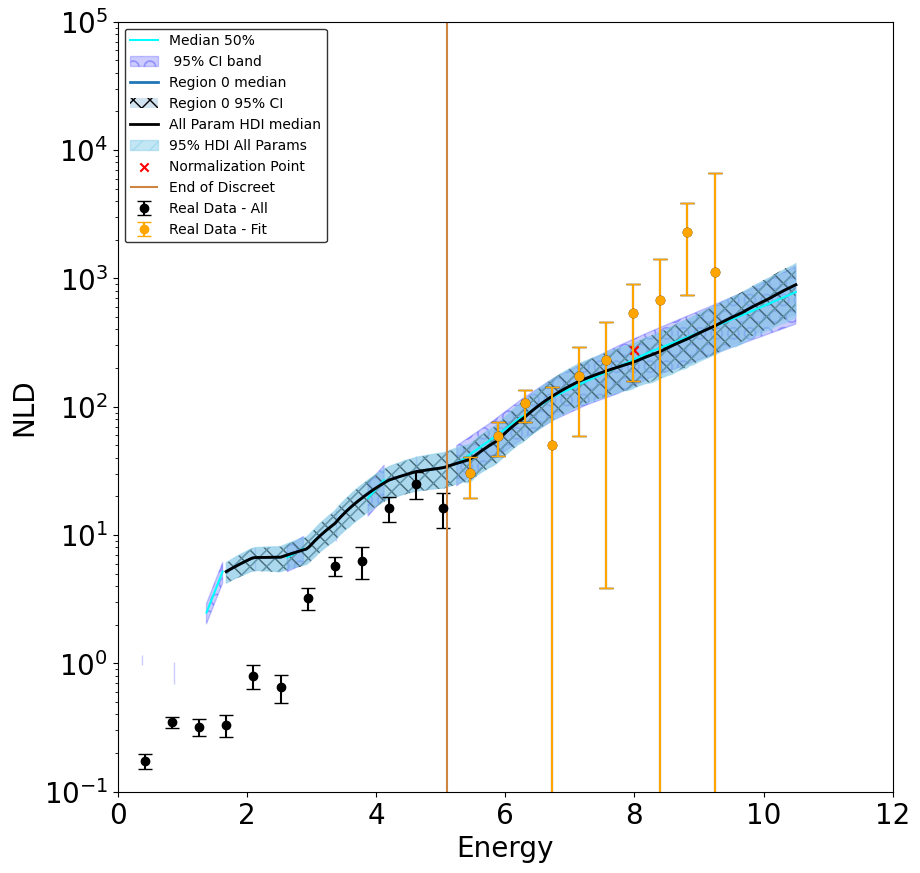

In [451]:

fig, ax = plt.subplots(figsize=(10,10),dpi=100)
prediction_color_number=4
hatches = ['xx','*','.','-','o','/']



#print(len(x_func),len(lower[1]),len(upper[1]))
#ax.fill_between(x_common, lwr_interp, upr_interp, where=~np.isnan(lwr_interp) & ~np.isnan(upr_interp), color = 'grey', alpha=0.7,label='95% Credible BAND')
#ax.fill_between(x_func, lower[1], upper[1], color='cyan', alpha=0.3,label='95% Credible BAND')

#ax.plot(median[0], median[1], color='black',linewidth=1,label='Median prediction')

############ CI #################
ax.plot(binters,med_y, color = 'cyan',label='Median 50%')
ax.fill_between(binters,ci_lower,ci_upper,where=~np.isnan(ci_lower) & ~np.isnan(ci_upper),color = 'blue',label = ' 95% CI band',hatch='O',alpha = .2)

#Peaks
i=0
for region, res in ci_results.items():
    #if region == 0:
    #    continue
    plt.plot(res["x_common"], res["median"], lw=2, label=f"Region {region} median")
    plt.fill_between(res["x_common"], res["lower"], res["upper"],hatch=hatches[i],alpha=0.2, label=f"Region {region} 95% CI")
    i=i+1

############## HDI ###########################
# All params
plt.plot(x_hdi, y_median, color="black", lw=2, label="All Param HDI median")
plt.fill_between(x_hdi, hdi_low, hdi_high,color="skyblue", alpha=0.5,hatch='//', label="95% HDI All Params")

#Peaks
'''
for i in range(len(mode_results)-1):
    plt.fill_between(mode_results[i]["x_common"], mode_results[i]["hdi_low"], mode_results[i]["hdi_high"],hatch=hatches[i],label=f'95% HDI of peak{i}',alpha=.4,color = colors[i])    
    plt.plot(mode_results[i]["x_common"], mode_results[i]["y_median"],label=f'Median of peak{i}',color = colors[i])

'''
############  Data #################
plt.scatter(8,275,label='Normalization Point',color='red',marker='x')
ax.errorbar(energy_data,nld_data, yerr=err_data, fmt='o',color='black', capsize=5,label='Real Data - All')
ax.errorbar(data[0],data[1], yerr=error, fmt='o',color='orange', capsize=5,label='Real Data - Fit')


plt.vlines(5.1,0,1e6,color='peru',label='End of Discreet')

plt.legend(fontsize=10,frameon=True, edgecolor='black',loc='best')
plt.xticks(np.arange(0,22,2))
plt.xlim(0,12)
plt.ylim(1e-1,1e5)
plt.yscale("log")

ax.set_xlabel('Energy',fontsize=20)
ax.set_ylabel('NLD',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()

In [242]:
#df_output = pd.DataFrame({'P_table (a0)':all_chains[:,0],'C_table (a1)':all_chains[:,1], 'LogLikelihood':all_chi2})
#df_output.to_csv('Bayes_nld__final.csv', index=False)